In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf # Python module for statistics
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/interim/02training.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 13 columns):
Unnamed: 0     1775 non-null int64
CV             1775 non-null int64
time           1775 non-null object
AHT            1775 non-null float64
abandoned      1775 non-null int64
avgAbandSec    1775 non-null float64
inQueueSec     1775 non-null float64
campaignid     1775 non-null int64
minute         1775 non-null int64
hour           1775 non-null int64
day            1775 non-null int64
week           1775 non-null int64
time24         1775 non-null object
dtypes: float64(3), int64(8), object(2)
memory usage: 180.4+ KB


#### **Call Volume Model Assessment**

In [4]:
df['time24'] =  df['time24'].astype('category')
df['day'] = df['day'].astype('category')
df['hour'] = df['hour'].astype('category')

In [5]:
models = {
    0: 'CV ~ day + AHT',
    1: 'CV ~ AHT',
    2: 'CV ~ day',
    3: 'CV ~ time24 + I(AHT**2):day ',
    4: 'CV ~ time24 + I(AHT**2):day - 1',
    5: 'CV ~ day:hour:AHT',
    6: 'CV ~ day + hour + AHT',
    7: 'CV ~ time24:I(AHT**2):day',
    8: 'CV ~ time24:I(AHT**3):day',
    9: 'CV ~ time24 + I(AHT**3):day',
    10: 'CV ~ time24:day:I(AHT**3)',
    11: 'CV ~ time24:day + I(AHT**3)'
}

Train index length: 1417
Test index length:  358


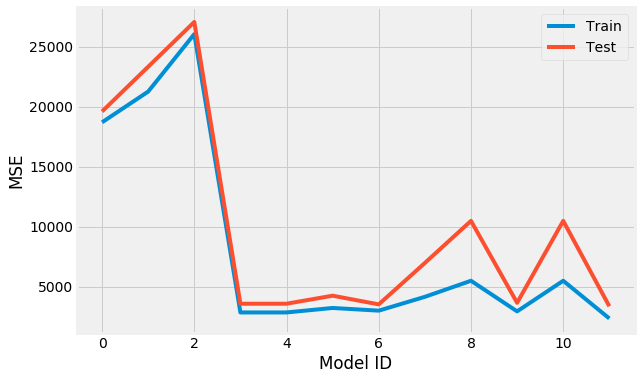

In [6]:
""" Reference

Code was taken from source below:

Linear regression in Python
 
https://andana.me/2019/01/11/python-regression.html

"""

index = np.random.rand(len(df)) < .8
train = df[index]
test = df[~index]
print(f'Train index length: {len(train)}')
print(f'Test index length:  {len(test)}')

class Validation_fits():
    def __init__(self, results):
        self.train_results = results
        self.regressand = results.summary().tables[0].data[0][1]
    def ssres(self, test=None):
        if test is None: return self.train_results.ssr
        else: return sum((test[self.regressand] - self.train_results.predict(test))**2)
    def rsquared(self, test=None):
        if test is None: return self.train_results.rsquared
        else:
            m = test[self.regressand].mean()
            return 1 - self.ssres(test=test)/sum((test[self.regressand]-m)**2)

train_mse = []
test_mse = []
for model_num in models:
    results = smf.ols(models[model_num], data=train).fit()
    v = Validation_fits(results)
    train_mse.append(v.train_results.ssr / len(train.CV))
    test_mse.append(v.ssres(test) / len(test.CV))
    
plt.figure(figsize=(10,6))
plt.style.use('fivethirtyeight')
plt.plot(range(len(train_mse)), train_mse)
plt.plot(range(len(test_mse)), test_mse)
plt.xlabel('Model ID')
plt.ylabel('MSE')
plt.legend(['Train','Test'])
plt.show()

In [7]:
print(f'Best Model:\n\n{models[3]}\n')
print(f'Train MSE:\t{train_mse[3]}')
print(f'Test MSE:\t{test_mse[3]}')

Best Model:

CV ~ time24 + I(AHT**2):day 

Train MSE:	2844.336606326844
Test MSE:	3570.723966597652


#### **Average Handle Time Model Assessment**

In [8]:
index = np.random.rand(len(df)) < .8
train = df[index]
test = df[~index]

model = 'AHT ~ C(time24):CV:day'

train_mse = []
test_mse = []
results = smf.ols(model, data=train).fit()
v = Validation_fits(results)
train_mse.append(v.train_results.ssr / len(train.CV))
test_mse.append(v.ssres(test) / len(test.CV))

# plt.figure(figsize=(10,6))
# plt.style.use('fivethirtyeight')
# plt.plot(range(len(train_mse)), train_mse)
# plt.plot(range(len(test_mse)), test_mse)
# plt.xlabel('Model ID')
# plt.ylabel('MSE')
# plt.legend(['Train','Test'])
# plt.show()

print(f'Train MSE:\t{train_mse[0]}')
print(f'Test MSE:\t{test_mse[0]}')

Train MSE:	3248.155628196824
Test MSE:	5156.30128985963
